In [7]:
# 알약 특성에 최적화된 증강 함수들

def get_pill_optimized_augmentation():
    """
    알약 특성에 최적화된 증강 변환
    - 180도 회전 (알약이 굴러다니는 특성 반영)
    - ImageNet 평균값으로 배경 채움
    - 의료 이미지에 적합한 증강
    """
    
    # ImageNet 평균값을 0-255 범위로 변환
    imagenet_mean_rgb = [int(0.485 * 255), int(0.456 * 255), int(0.406 * 255)]  # [123, 116, 103]
    
    return transforms.Compose([
        transforms.Resize(224),
        transforms.CenterCrop(224),
        transforms.RandomRotation(180, fill=imagenet_mean_rgb),  # 180도 회전 + ImageNet 평균값
        transforms.ColorJitter(
            brightness=0.3,
            contrast=0.3,
            saturation=0.2,
            hue=0.1
        ),
        transforms.RandomAffine(
            degrees=0,
            translate=(0.1, 0.1),
            scale=(0.9, 1.1),
            fill=imagenet_mean_rgb  # ImageNet 평균값으로 채움
        ),
        transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
        # PIL 이미지 상태에서 시각화하기 위해 ToTensor()와 Normalize() 제외
    ])

def get_training_augmentation():
    """
    실제 학습에 사용할 증강 변환 (ToTensor + Normalize 포함)
    """
    
    # ImageNet 평균값을 0-255 범위로 변환
    imagenet_mean_rgb = [int(0.485 * 255), int(0.456 * 255), int(0.406 * 255)]
    
    return transforms.Compose([
        transforms.Resize(224),
        transforms.CenterCrop(224),
        # 알약 특성상 좌우상하 반전은 제거 (각인 문자 때문에)
        transforms.RandomRotation(180, fill=imagenet_mean_rgb),  # 180도 회전 (굴러다니는 특성)
        transforms.ColorJitter(
            brightness=0.2,    # 조명 변화
            contrast=0.25,     # 대비 변화
            saturation=0.15,   # 채도는 약간만 (색상이 중요한 식별 요소)
            hue=0.05          # 색조 변화 최소화
        ),
        transforms.RandomAffine(
            degrees=0,
            translate=(0.1, 0.1),
            scale=(0.95, 1.05),  # 크기 변화 보수적으로
            fill=imagenet_mean_rgb
        ),
        transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),  # 블러 강도 조정
        transforms.ToTensor(),
        # ImageNet 정규화 (사전학습 모델과 호환)
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                           std=[0.229, 0.224, 0.225])
    ])

In [8]:
def visualize_original_vs_augmented_samples(yaml_path, num_rows=10):
    """
    원본 데이터와 증강 데이터를 비교하여 시각화하는 함수
    
    Args:
        yaml_path: YOLO 데이터셋 yaml 파일 경로
        num_rows: 표시할 행의 수 (기본값 10)
    """
    from torch.utils.data import Subset
    import matplotlib.pyplot as plt
    import numpy as np
    
    # 원본 데이터셋 생성 (transform 없이)
    original_dataset = YOLOToClassificationDataset(
        yaml_path=yaml_path,
        split='train',
        transform=None  # transform 없이 원본 이미지만
    )
    
    # 증강용 transform 정의 (알약 최적화 버전)
    strong_augment = get_pill_optimized_augmentation()
    
    # Figure 생성 (2열 n행)
    fig, axes = plt.subplots(num_rows, 2, figsize=(8, 4*num_rows))
    fig.suptitle(f'원본 vs 증강 데이터 비교 ({num_rows}개 샘플)', fontsize=16, y=0.98)
    
    # 랜덤하게 샘플 선택
    np.random.seed(42)  # 재현 가능한 결과를 위해
    sample_indices = np.random.choice(len(original_dataset), num_rows, replace=False)
    
    for row_idx, sample_idx in enumerate(sample_indices):
        # 원본 이미지 가져오기
        original_image, class_id = original_dataset[sample_idx]
        class_name = original_dataset.class_names[class_id]
        
        # 원본 이미지가 PIL이 아닌 경우 처리
        if not isinstance(original_image, Image.Image):
            if isinstance(original_image, torch.Tensor):
                original_image = TF.to_pil_image(original_image)
        
        # 증강 이미지 생성
        augmented_image = strong_augment(original_image)
        
        # 원본 이미지 표시 (왼쪽)
        axes[row_idx, 0].imshow(original_image)
        axes[row_idx, 0].set_title(f'원본 - {class_name}', fontsize=12)
        axes[row_idx, 0].axis('off')
        
        # 증강 이미지 표시 (오른쪽)
        axes[row_idx, 1].imshow(augmented_image)
        axes[row_idx, 1].set_title(f'증강 - {class_name}', fontsize=12)
        axes[row_idx, 1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # 통계 정보 출력
    print(f"총 {num_rows}개의 샘플을 표시했습니다.")
    print(f"원본 데이터셋 크기: {len(original_dataset)} samples")
    
    # 클래스별 분포도 간단히 표시
    class_counts = {}
    for idx in sample_indices:
        _, class_id = original_dataset[idx]
        class_name = original_dataset.class_names[class_id]
        class_counts[class_name] = class_counts.get(class_name, 0) + 1
    
    print(f"\n표시된 샘플의 클래스 분포:")
    for class_name, count in sorted(class_counts.items()):
        print(f"  {class_name}: {count}개")

In [9]:
def convert_yolo_to_coco_format(train_dataset, val_dataset, test_dataset, output_dir, image_format='jpg'):
    """
    YOLO 데이터셋을 COCO 형식으로 변환하여 저장하는 함수
    
    Args:
        train_dataset: YOLOToClassificationDataset (train)
        val_dataset: YOLOToClassificationDataset (val) 
        test_dataset: YOLOToClassificationDataset (test)
        output_dir: 출력 폴더 경로
        image_format: 저장할 이미지 형식 ('jpg' 또는 'png')
    """
    import json
    from datetime import datetime
    
    # 출력 디렉토리 구조 생성
    os.makedirs(output_dir, exist_ok=True)
    
    # COCO 형식 기본 구조
    def create_coco_structure(description, split_name):
        return {
            "info": {
                "description": description,
                "url": "",
                "version": "1.0",
                "year": datetime.now().year,
                "contributor": "YOLO to COCO Converter",
                "date_created": datetime.now().isoformat()
            },
            "licenses": [
                {
                    "id": 1,
                    "name": "Unknown License",
                    "url": ""
                }
            ],
            "images": [],
            "annotations": [],
            "categories": []
        }
    
    # 각 분할별로 처리
    datasets_info = [
        (train_dataset, 'train', 'Training dataset'),
        (val_dataset, 'val', 'Validation dataset'), 
        (test_dataset, 'test', 'Test dataset')
    ]
    
    for dataset, split_name, description in datasets_info:
        if dataset is None or len(dataset) == 0:
            print(f"경고: {split_name} 데이터셋이 비어있거나 None입니다. 건너뜁니다.")
            continue
            
        print(f"{split_name} 데이터셋 변환 중... ({len(dataset)} samples)")
        
        # COCO 구조 초기화
        coco_data = create_coco_structure(description, split_name)
        
        # 이미지 및 주석 디렉토리 생성
        images_dir = os.path.join(output_dir, f'{split_name}2017')
        os.makedirs(images_dir, exist_ok=True)
        
        # 카테고리 정보 추가 (한 번만)
        if hasattr(dataset, 'class_names'):
            class_names = dataset.class_names
        elif hasattr(dataset, 'dataset') and hasattr(dataset.dataset, 'class_names'):
            # ConcatDataset의 경우
            for ds in dataset.datasets:
                if hasattr(ds, 'class_names'):
                    class_names = ds.class_names
                    break
                elif hasattr(ds, 'dataset') and hasattr(ds.dataset, 'class_names'):
                    class_names = ds.dataset.class_names
                    break
        else:
            class_names = [f"class_{i}" for i in range(10)]  # 기본값
            
        for i, class_name in enumerate(class_names):
            coco_data["categories"].append({
                "id": i,
                "name": class_name,
                "supercategory": "pill"
            })
        
        # 이미지별 그룹핑을 위한 딕셔너리
        image_groups = {}
        annotation_id = 1
        
        # 모든 샘플을 순회하며 이미지별로 그룹핑
        print(f"{split_name} 샘플들을 이미지별로 그룹핑 중...")
        pbar = tqdm(range(len(dataset)), desc=f"Processing {split_name}")
        
        for idx in pbar:
            try:
                # 데이터셋 타입에 따른 처리
                if hasattr(dataset, 'get_item'):
                    # 원본 YOLOToClassificationDataset
                    crop_image, class_id, original_image_path, bbox = dataset.get_item(idx)
                elif hasattr(dataset, 'dataset') and hasattr(dataset.dataset, 'get_item'):
                    # ConcatDataset 내부의 원본 데이터셋 접근
                    crop_image, class_id = dataset[idx]
                    original_image_path = f"unknown_{idx}.jpg"
                    bbox = [0, 0, 224, 224]  # 기본값
                else:
                    crop_image, class_id = dataset[idx]
                    original_image_path = f"sample_{idx}.jpg"
                    bbox = [0, 0, 224, 224]
                
                # 이미지 파일명 생성
                base_filename = os.path.basename(original_image_path).replace('.jpg', '').replace('.png', '')
                image_filename = f"{base_filename}_{class_id:03d}_{idx:06d}.{image_format}"
                image_path = os.path.join(images_dir, image_filename)
                
                # crop된 이미지 저장
                if isinstance(crop_image, torch.Tensor):
                    # 정규화 해제
                    if crop_image.shape[0] == 3:  # (C, H, W)
                        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
                        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
                        crop_image = crop_image * std + mean
                        crop_image = torch.clamp(crop_image, 0, 1)
                    crop_image = TF.to_pil_image(crop_image)
                
                # 이미지 저장
                crop_image.save(image_path)
                crop_width, crop_height = crop_image.size
                
                # COCO 이미지 정보 추가
                image_info = {
                    "id": idx + 1,
                    "width": crop_width,
                    "height": crop_height,
                    "file_name": image_filename,
                    "license": 1,
                    "flickr_url": "",
                    "coco_url": "",
                    "date_captured": datetime.now().isoformat()
                }
                coco_data["images"].append(image_info)
                
                # COCO 주석 정보 추가 (전체 이미지가 해당 클래스)
                annotation_info = {
                    "id": annotation_id,
                    "image_id": idx + 1,
                    "category_id": class_id,
                    "segmentation": [],
                    "area": crop_width * crop_height,
                    "bbox": [0, 0, crop_width, crop_height],  # 전체 이미지
                    "iscrowd": 0
                }
                coco_data["annotations"].append(annotation_info)
                annotation_id += 1
                
                pbar.set_postfix_str(f'{class_names[class_id]} ({image_filename})')
                
            except Exception as e:
                print(f"경고: 샘플 {idx} 처리 중 오류: {e}")
                continue
        
        # JSON 파일 저장
        json_filename = f"instances_{split_name}2017.json"
        json_path = os.path.join(output_dir, json_filename)
        
        with open(json_path, 'w', encoding='utf-8') as f:
            json.dump(coco_data, f, indent=2, ensure_ascii=False)
        
        print(f"{split_name} 변환 완료:")
        print(f"   이미지: {len(coco_data['images'])}개 → {images_dir}")
        print(f"   주석: {json_path}")
        print(f"   카테고리: {len(coco_data['categories'])}개")

In [10]:
def test_coco_dataset_loading(coco_root_dir):
    """
    변환된 COCO 데이터셋 로딩 테스트
    
    Args:
        coco_root_dir: COCO 형식으로 변환된 데이터가 있는 루트 디렉토리
    """
    print("COCO 데이터셋 로딩 테스트...")
    
    splits = ['train', 'val', 'test']
    
    for split in splits:
        image_folder = os.path.join(coco_root_dir, f'{split}2017')
        annotation_file = os.path.join(coco_root_dir, f'instances_{split}2017.json')
        
        if not os.path.exists(image_folder) or not os.path.exists(annotation_file):
            print(f"경고: {split} 데이터가 없습니다. 건너뜁니다.")
            continue
        
        try:
            # CocoDetection 데이터셋 생성
            dataset = CocoDetection(root=image_folder, annFile=annotation_file)
            
            print(f"{split} 데이터셋 로딩 성공:")
            print(f"   총 이미지 수: {len(dataset)}")
            
            if len(dataset) > 0:
                # 첫 번째 샘플 테스트
                image, target = dataset[0]
                print(f"   첫 번째 이미지 크기: {image.size}")
                print(f"   주석 개수: {len(target)}")
                if len(target) > 0:
                    print(f"   첫 번째 주석: {target[0]}")
            
            print()
            
        except Exception as e:
            print(f"오류: {split} 데이터셋 로딩 실패: {e}")

def save_datasets_as_coco_format():
    """
    현재 데이터셋들을 COCO 형식으로 저장하는 메인 함수
    """
    
    # 출력 디렉토리 설정
    output_dir = os.path.join(os.path.dirname(yaml_path), "coco_format")
    
    print("YOLO → COCO 형식 변환 시작...")
    print(f"출력 디렉토리: {output_dir}")
    
    # 원본 데이터셋 생성 (transform 없이 순수 이미지만)
    original_train_dataset = YOLOToClassificationDataset(
        yaml_path=yaml_path,
        split='train',
        transform=None
    )
    
    original_val_dataset = YOLOToClassificationDataset(
        yaml_path=yaml_path, 
        split='val',
        transform=None
    )
    
    original_test_dataset = YOLOToClassificationDataset(
        yaml_path=yaml_path,
        split='test', 
        transform=None
    )
    
    # COCO 형식으로 변환
    convert_yolo_to_coco_format(
        train_dataset=original_train_dataset,
        val_dataset=original_val_dataset, 
        test_dataset=original_test_dataset,
        output_dir=output_dir,
        image_format='jpg'
    )
    
    print("모든 변환 완료!")
    
    # 로딩 테스트
    test_coco_dataset_loading(output_dir)
    
    # 디렉토리 구조 출력
    print("생성된 디렉토리 구조:")
    print_dir_tree(output_dir, max_depth=2)
    
    return output_dir

In [11]:
def check_augmentation_fill_behavior():
    """
    증강 변환 시 여백 채움 동작을 확인하는 함수
    """
    import matplotlib.pyplot as plt
    
    # 원본 데이터셋에서 샘플 가져오기
    original_dataset = YOLOToClassificationDataset(
        yaml_path=yaml_path,
        split='train',
        transform=None
    )
    
    # ImageNet 평균값
    imagenet_mean_rgb = [int(0.485 * 255), int(0.456 * 255), int(0.406 * 255)]
    
    # 여러 가지 fill 옵션으로 변환 정의
    transform_configs = [
        {
            'name': '기본 설정 (검은색)',
            'transform': transforms.Compose([
                transforms.Resize(224),
                transforms.RandomRotation(45),  # 기본: fill=0 (검은색)
                transforms.RandomAffine(degrees=0, translate=(0.2, 0.2))  # 기본: fill=0
            ])
        },
        {
            'name': '흰색 여백',
            'transform': transforms.Compose([
                transforms.Resize(224),
                transforms.RandomRotation(45, fill=255),  # 흰색으로 채움
                transforms.RandomAffine(degrees=0, translate=(0.2, 0.2), fill=255)
            ])
        },
        {
            'name': 'ImageNet 평균값',
            'transform': transforms.Compose([
                transforms.Resize(224),
                transforms.RandomRotation(45, fill=imagenet_mean_rgb),
                transforms.RandomAffine(degrees=0, translate=(0.2, 0.2), fill=imagenet_mean_rgb)
            ])
        }
    ]
    
    # 샘플 이미지로 테스트
    sample_image, class_id = original_dataset[0]
    class_name = original_dataset.class_names[class_id]
    
    fig, axes = plt.subplots(2, len(transform_configs) + 1, figsize=(16, 8))
    
    # 원본 이미지 표시
    axes[0, 0].imshow(sample_image)
    axes[0, 0].set_title('원본 이미지', fontsize=12)
    axes[0, 0].axis('off')
    axes[1, 0].axis('off')  # 빈 공간
    
    # 각 설정별로 증강 결과 표시
    for i, config in enumerate(transform_configs):
        # 두 번 적용해서 랜덤성 확인
        for row in range(2):
            augmented = config['transform'](sample_image)
            axes[row, i + 1].imshow(augmented)
            axes[row, i + 1].set_title(f"{config['name']}\n(적용 {row+1})", fontsize=10)
            axes[row, i + 1].axis('off')
    
    plt.suptitle(f'증강 변환 시 여백 채움 비교 - {class_name}', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    print("=== 현재 사용 중인 증강 설정 분석 ===")
    print("1. RandomRotation: fill 매개변수 기본값 = 0 (검은색)")
    print("2. RandomAffine: fill 매개변수 기본값 = 0 (검은색)")
    print("3. 개선안: ImageNet 평균값 사용으로 자연스러운 배경")
    print(f"4. ImageNet RGB 평균값: {imagenet_mean_rgb} (회갈색 계열)")
    print()
    print("=== 알약 증강의 특별 고려사항 ===")
    print("• 180도 회전: 알약이 굴러다니는 물리적 특성 반영")
    print("• 좌우상하 반전 제거: 각인된 문자/숫자 때문에 반전 불가")
    print("• ImageNet 평균값 배경: 사전학습 모델과의 호환성")
    print("• 색상 변화 최소화: 색상이 중요한 식별 요소")

## 검토 결과 적용된 주요 개선사항

### 1. 증강 변환 최적화
- **180도 회전**: 알약이 굴러다니는 물리적 특성을 반영하여 180도 회전 적용
- **ImageNet 평균값 배경**: 검은색 대신 ImageNet 평균값 [123, 116, 103]으로 여백 채움
- **반전 제거**: 알약의 각인 문자/숫자 때문에 좌우상하 반전 제거
- **색상 변화 최소화**: 알약의 색상이 중요한 식별 요소이므로 hue 변화 최소화

### 2. 시각화 함수 개선  
- **원본 vs 증강 비교**: 2열 구조로 원본과 증강된 이미지를 나란히 비교
- **행 수 조절 가능**: num_rows 매개변수로 표시할 샘플 수 조절
- **클래스별 분포**: 시각화된 샘플의 클래스 분포 통계 제공

### 3. COCO 형식 변환 함수
- **표준 COCO 구조**: PyTorch CocoDetection과 호환되는 표준 형식
- **crop된 알약 이미지**: 개별 알약을 crop하여 분류 작업에 최적화
- **자동 테스트**: 변환 후 자동으로 로딩 테스트 수행

### 4. 배경 채움 방식 비교
- **다양한 fill 옵션**: 검은색, 흰색, ImageNet 평균값 비교
- **시각적 검증**: 각 방식의 효과를 직접 확인 가능
- **의료 이미지 특성**: 알약 이미지에 가장 적합한 방식 선택

# [초급 프로젝트] 4팀_김명환 - 증강데이타검토

---
---

# 환경설정
    - 라이브러리 설치 및 로딩
    - 사용자 함수 사용

In [12]:
!pip install -q gdown
!pip install -q albumentations
!pip install -q ultralytics
!pip install -q -U ultralytics
!pip install -q nbformat
!pip install -q roboflow
!pip install -q opencv-python
!pip install -q opencv-python-headless
!pip install -q wandb
!pip install -q timm
!pip install -q torchvision
#!pip install -q torch torchvision tqdm pillow matplotlib

print("로딩완료")

로딩완료


In [13]:
!wandb login 86a7b8c07184b2efdfb116546a17b1905e41cb5d

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\sw1\_netrc
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


In [14]:
# 기본 라이브러리 (중복 제거 및 정리)

# --- Scikit-learn: 데이터 전처리, 모델, 평가 ---
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.datasets import (
    fetch_california_housing, load_iris, make_moons, make_circles,
    load_breast_cancer, load_wine
)
from sklearn import datasets
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, mean_squared_error, average_precision_score

# --- 이미지 처리 ---
import cv2
from PIL import Image, ImageFilter, ImageDraw
import albumentations as A

# --- PyTorch: 딥러닝 관련 ---
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, Subset
# 문제 있는 v2 import 제거하고 필요시에만 개별적으로 import
# from torchvision.transforms import v2, functional as TF
from torchvision.transforms import functional as TF
from torchvision.datasets import CocoDetection
from torch.nn import CrossEntropyLoss
from collections import OrderedDict

# --- COCO 데이터셋 관련 ---
from pycocotools.coco import COCO
from pycocotools import mask as coco_mask

# --- 딥러닝 모델 ---
import timm

# --- 기본 라이브러리 ---
import os
import sys
import re
import csv
import copy
import json
import math
import random
import yaml
import shutil
import requests
import xml.etree.ElementTree as ET
from pathlib import Path

# --- 데이터 분석 및 시각화 ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# --- 시간 관련 ---
from datetime import datetime, timezone, timedelta
import pytz

# --- 진행률 표시 ---
import IPython.display
from tqdm.notebook import tqdm

# --- 시간대 설정 ---
__kst = pytz.timezone('Asia/Seoul')

# --- GPU 설정 ---
__device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
__device_cpu = torch.device('cpu')

# --- 재현 가능한 결과를 위한 시드 설정 ---
np.random.seed(42)
torch.manual_seed(42)
if __device.type == 'cuda':
    torch.cuda.manual_seed_all(42)

print(f"라이브러리 로드 완료 사용장치: {__device}")

라이브러리 로드 완료 사용장치: cpu


In [15]:
from urllib.request import urlretrieve; urlretrieve("https://raw.githubusercontent.com/c0z0c/jupyter_hangul/refs/heads/beta/helper_c0z0c_dev.py", "helper_c0z0c_dev.py")
import importlib
import helper_c0z0c_dev as helper
importlib.reload(helper)

🌐 https://c0z0c.github.io/jupyter_hangul
ℹ️ NumPy 2.1.3 (v2.x+): 호환성 모드 적용됨
✅ 설정 완료: 한글 폰트, plt 전역 등록, pandas 확장, 캐시 기능
pd commit 저장 경로 = d:\GoogleDrive\codeit_ai_health_eat\scripts\김명환
🌐 https://c0z0c.github.io/jupyter_hangul
ℹ️ NumPy 2.1.3 (v2.x+): 호환성 모드 적용됨
✅ 설정 완료: 한글 폰트, plt 전역 등록, pandas 확장, 캐시 기능
pd commit 저장 경로 = d:\GoogleDrive\codeit_ai_health_eat\scripts\김명환


<module 'helper_c0z0c_dev' from 'd:\\GoogleDrive\\codeit_ai_health_eat\\scripts\\김명환\\helper_c0z0c_dev.py'>

In [16]:
# OS 및 경로 관련 라이브러리 임포트
import os, sys
from pathlib import Path

# 유틸리티 함수 디렉토리 경로 설정 (Colab 환경 여부에 따라 다르게 지정)
utils_dir = None
if helper.is_colab:
    # Colab 환경일 경우 Google Drive 경로 사용
    utils_dir = "/content/drive/MyDrive/codeit_ai_health_eat/src/python_modules/utils"
else:
    # 로컬 환경일 경우 현재 드라이브 기준 경로 사용
    utils_dir = os.path.join(Path.cwd().drive + '\\\\', 'GoogleDrive', "codeit_ai_health_eat", "src", "python_modules", "utils")

print("utils_dir:", utils_dir)

# 유틸리티 함수 경로를 파이썬 모듈 검색 경로에 추가
sys.path.append(str(utils_dir))
print("sys.path:", sys.path)

# health_ea_utils 모듈 임포트 및 최신화(reload)
import importlib
import health_ea_utils as heu
importlib.reload(heu)
from health_ea_utils import *

# helper 및 health_ea_utils 파일 경로 출력 (디버깅용)
print("helper.__file__:", helper.__file__)
print("health_ea_utils.__file__:", heu.__file__)

utils_dir: d:\\GoogleDrive\codeit_ai_health_eat\src\python_modules\utils
sys.path: ['c:\\Users\\sw1\\anaconda3\\envs\\env_colab_250827\\python310.zip', 'c:\\Users\\sw1\\anaconda3\\envs\\env_colab_250827\\DLLs', 'c:\\Users\\sw1\\anaconda3\\envs\\env_colab_250827\\lib', 'c:\\Users\\sw1\\anaconda3\\envs\\env_colab_250827', '', 'C:\\Users\\sw1\\AppData\\Roaming\\Python\\Python310\\site-packages', 'c:\\Users\\sw1\\anaconda3\\envs\\env_colab_250827\\lib\\site-packages', 'c:\\Users\\sw1\\anaconda3\\envs\\env_colab_250827\\lib\\site-packages\\win32', 'c:\\Users\\sw1\\anaconda3\\envs\\env_colab_250827\\lib\\site-packages\\win32\\lib', 'c:\\Users\\sw1\\anaconda3\\envs\\env_colab_250827\\lib\\site-packages\\Pythonwin', 'd:\\\\GoogleDrive\\codeit_ai_health_eat\\src\\python_modules\\utils']
🌐 https://c0z0c.github.io/jupyter_hangul
ℹ️ NumPy 2.1.3 (v2.x+): 호환성 모드 적용됨
✅ 설정 완료: 한글 폰트, plt 전역 등록, pandas 확장, 캐시 기능
pd commit 저장 경로 = d:\GoogleDrive\codeit_ai_health_eat\scripts\김명환
🌐 https://c0z0c.github.io

In [17]:
def get_tqdm_kwargs():
    """Widget 오류를 방지하는 안전한 tqdm 설정"""
    return {
        'disable': False,
        'leave': True,
        'file': sys.stdout,
        'ascii': True,  # ASCII 문자만 사용
        'dynamic_ncols': False,
#        'ncols': 80  # 고정 폭
    }

def drive_root():
    """
    Google Drive의 최상위 경로를 반환하는 함수입니다.
    - 로컬 환경(Windows): D:\GoogleDrive
    - Colab 환경: /content/drive/MyDrive
    프로젝트 내에서 데이터, 모델, 설정 파일 등 경로를 일관되게 관리할 때 사용합니다.
    """
    root_path = os.path.join(Path.cwd().drive + '\\', "GoogleDrive")
    if helper.is_colab:
        root_path = os.path.join("/content/drive/MyDrive")
    return root_path

def get_path_modeling(add_path = None):
    """
    get_path_modeling() 함수는 모델링 관련 파일(예: 학습 결과, 체크포인트, 로그 등)을 저장할 경로를 반환합니다.
    기본적으로 Google Drive의 루트 경로(drive_root()) 아래 "modeling_yolo" 폴더를 기준으로 경로를 생성합니다.
    추가 하위 경로가 필요할 경우 add_path 인자를 통해 세부 폴더까지 지정할 수 있습니다.
    예시:
    get_path_modeling() → modeling_yolo (로컬)
    get_path_modeling("exp1") → D:\GoogleDrive\modeling_yolo\exp1
    Colab 환경에서는 /content/drive/MyDrive/modeling_yolo로 반환됩니다.
    """

    modeling_path = "modeling_yolo"
    path = os.path.join(drive_root(),modeling_path)
    if add_path is not None:
        path = os.path.join(path,add_path)
    return path

def get_path_modeling_release(add_path = None):
    """
    get_path_modeling_release() 함수는 모델링 결과물(예: 학습 결과, 체크포인트, 로그 등)을 저장할 경로를 반환합니다.
    기본적으로 Google Drive의 루트 경로(drive_root()) 아래 "modeling_yolo" 폴더를 기준으로 경로를 생성합니다.
    추가 하위 경로가 필요할 경우 add_path 인자를 통해 세부 폴더까지 지정할 수 있습니다.
    예시:
    get_path_modeling_release() → modeling_yolo (로컬)
    get_path_modeling_release("exp1") → D:\GoogleDrive\modeling_yolo\exp1
    Colab 환경에서는 /content/drive/MyDrive/modeling_yolo로 반환됩니다._
    """
    modeling_path = "modeling_yolo"
    path = os.path.join(drive_root(),modeling_path)
    if add_path is not None:
        path = os.path.join(path,add_path)
    return path

def print_dir_tree(root, max_depth=2, list_count=3, indent=""):
    """
    지정한 폴더(root) 하위의 디렉토리 구조를 트리 형태로 출력하는 함수입니다.

    Args:
        root: 시작 경로(폴더)
        max_depth: 출력할 최대 깊이(디폴트 2)
        list_count: 파일 개수가 많을 때 몇 개만 출력할지(디폴트 3)
        indent: 들여쓰기(재귀적으로 사용)
    """
    import os
    if max_depth < 0:
        return
    try:
        items = os.listdir(root)
    except Exception as e:
        print(indent + f"[Error] {e}")
        return

    img_count = len([f for f in os.listdir(root) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.xml', '.inf', '.txt'))])
    for item in items:
        path = os.path.join(root, item)
        if os.path.isdir(path):
            print(indent + "|-- "+ item)
            # 이미지 파일 개수만 출력
            img_count = len([f for f in os.listdir(path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.xml', '.inf', '.txt'))])
            if img_count > list_count:
                print(indent + "   "+ f"[데이터파일: {img_count}개]")
            print_dir_tree(root=path, max_depth=max_depth-1, list_count=list_count, indent=indent + "   ")
        else:
            if list_count < img_count and item.lower().endswith(('.jpg', '.jpeg', '.png', '.xml', '.inf', '.txt')):
                continue
            print(indent + "|-- "+ item)

def save_model_dict(model, path, pth_name, kwargs=None):
    """모델 state_dict와 추가 정보를 저장"""
    def safe_makedirs(path):
        """안전한 디렉토리 생성"""
        if os.path.exists(path) and not os.path.isdir(path):
            os.remove(path)  # 파일이면 삭제
        os.makedirs(path, exist_ok=True)

    # 디렉토리 생성
    safe_makedirs(path)

    # 모델 구조 정보 추출
    model_info = {
        'class_name': model.__class__.__name__,
        'init_args': {},
        'str': str(model),
        'repr': repr(model),
        'modules': [m.__class__.__name__ for m in model.modules()],
    }

    # 생성자 인자 자동 추출(가능한 경우)
    if hasattr(model, '__dict__'):
        for key in ['in_ch', 'base_ch', 'num_classes', 'out_ch']:
            if hasattr(model, key):
                model_info['init_args'][key] = getattr(model, key)

    # kwargs 처리
    extra_info = {}
    if kwargs is not None:
        if isinstance(kwargs, str):
            extra_info = json.loads(kwargs)
        elif isinstance(kwargs, dict):
            extra_info = kwargs

    model_info.update(extra_info)

    # 저장할 dict 구성
    save_dict = {
        'model_state': model.state_dict(),
        'class_name': model.__class__.__name__,
        'model_info': model_info,
    }

    save_path = os.path.join(path, f"{pth_name}.pth")
    torch.save(save_dict, save_path)
    return save_path

def load_model_dict(path, pth_name=None):
    """
    save_model_dict로 저장한 모델을 불러오는 함수
    반환값: (model_state, model_info)
    """
    import torch
    load_path = path
    if pth_name is not None:
        load_path = os.path.join(path, f"{pth_name}.pth")
    checkpoint = torch.load(load_path, map_location='cpu', weights_only=False)  # <-- 여기 추가
    model_state = checkpoint.get('model_state')
    model_info = checkpoint.get('model_info')
    model_info['file_name'] = os.path.basename(load_path)
    return model_state, model_info


def search_pth_files(base_path):
    """
    입력된 경로의 하위 폴더들에서 pth 파일들을 검색
    """
    pth_files = []

    if not os.path.exists(base_path):
        print(f"경로가 존재하지 않습니다: {base_path}")
        return pth_files

    print(f"pth 파일 검색 시작: {base_path}")

    # 하위 폴더들을 순회하며 pth 파일 검색
    for root, dirs, files in os.walk(base_path):
        for file in files:
            if file.endswith('.pth'):
                pth_path = os.path.join(root, file)
                pth_files.append(pth_path)

    # 결과 정리 및 출력
    if pth_files:
        print(f"\n발견된 pth 파일들 ({len(pth_files)}개):")
        for i, pth_file in enumerate(pth_files, 1):
            # 상대 경로로 표시 (base_path 기준)
            rel_path = os.path.relpath(pth_file, base_path)
            print(f" {i:2d}. {rel_path}")
    else:
        print("pth 파일을 찾을 수 없습니다.")

    return pth_files

def print_json_tree(data, indent="", max_depth=4, _depth=0, list_count=2, print_value=True):
    """
    JSON 객체를 지정한 단계(max_depth)까지 트리 형태로 출력
    - list 타입은 3개 이상일 때 개수만 출력
    - 하위 노드가 값일 경우 key(type) 형태로 출력
    - print_value=True일 때 key(type): 값 형태로 출력
    """
    if _depth > max_depth:
        return
    if isinstance(data, dict):
        for key, value in data.items():
            if isinstance(value, (dict, list)):
                print(f"{indent}|-- {key}")
                print_json_tree(value, indent + "    ", max_depth, _depth + 1, list_count, print_value)
            else:
                if print_value:
                    print(f"{indent}|-- {key}({type(value).__name__}): {value if len(str(value)) < 100 else f'{str(value)[:30]}...'}")
                else:
                    print(f"{indent}|-- {key}({type(value).__name__})")
    elif isinstance(data, list):
        if len(data) > list_count:
            print(f"{indent}|-- [list] ({len(data)} items)")
        else:
            for i, item in enumerate(data):
                if isinstance(item, (dict, list)):
                    print(f"{indent}|-- [{i}]")
                    print_json_tree(item, indent + "    ", max_depth, _depth + 1, list_count, print_value)
                else:
                    if print_value:
                        print(f"{indent}|-- [{i}]({type(item).__name__}): {item if len(str(item)) < 100 else f'{str(item)[:30]}...'}")
                    else:
                        print(f"{indent}|-- [{i}]({type(item).__name__})")
    else:
        if print_value:
            print(f"{indent}{type(data).__name__}: {data if len(str(data)) < 100 else f'{str(data)[:30]}...'}")
        else:
            print(f"{indent}{type(data).__name__}")

def print_git_tree(data, indent="", max_depth=3, _depth=0):
    """
    PyTorch tensor/딕셔너리/리스트를 git tree 스타일로 출력
    """
    import torch
    import numpy as np

    if _depth > max_depth:
        return
    if isinstance(data, dict):
        for key, value in data.items():
            print(f"{indent}├─ {key} [{type(value).__name__}]")
            print_git_tree(value, indent + "│  ", max_depth, _depth + 1)
    elif isinstance(data, (list, tuple)):
        for i, item in enumerate(data):
            print(f"{indent}├─ [{i}] [{type(item).__name__}]")
            print_git_tree(item, indent + "│  ", max_depth, _depth + 1)
    elif torch.is_tensor(data):
        shape = tuple(data.shape)
        dtype = str(data.dtype)
        preview = str(data)
        preview_str = preview[:80] + ("..." if len(preview) > 80 else "")
        print(f"{indent}└─ Tensor shape={shape} dtype={dtype} preview={preview_str}")
    elif isinstance(data, np.ndarray):
        shape = data.shape
        dtype = data.dtype
        preview = str(data)
        preview_str = preview[:80] + ("..." if len(preview) > 80 else "")
        print(f"{indent}└─ ndarray shape={shape} dtype={dtype} preview={preview_str}")
    else:
        val_str = str(data)
        print(f"{indent}└─ {type(data).__name__}: {val_str[:80]}{'...' if len(val_str)>80 else ''}")


print("유틸리티 함수 로드 완료")

유틸리티 함수 로드 완료


# 데이타 다운로드

In [18]:
# download_files 변수 예시 (Google Drive 및 Naver MyBox 링크)
# 여러 버전의 데이터셋 다운로드 링크를 주석으로 관리

# download_files={
#     'yolo_label_one_class' : r'https://drive.google.com/file/d/177_86k4BuT6JnFnq7ZHJtEjp7jaRbCl2/view?usp=sharing',
#     'yolo_label' : r'https://drive.google.com/file/d/1nc-WFcw7lCS7s7VGzN9Kxh80PiBBggez/view?usp=sharing',
#     'yolo_resize_one_class' : r'https://drive.google.com/file/d/1Ak0EvkMnuwvcAFvTO-zovIgVcNlROjsS/view?usp=sharing',
#     'yolo_resize' : r'https://drive.google.com/file/d/1kpo57qOJhEhrkuzUCEh57ILB5xSPVoFv/view?usp=sharing',
# }

# download_files={
#     'yolo_label' : r'https://fs.mybox.naver.com/file/download.api?resourceKey=YzB6MGN8MzQ3MjU5Nzc1ODU5OTkzNTMyOHxGfDA&svcType=MYBOX-WEB&time=1757776010785',
#     'yolo_label_one_class' : r'https://fs.mybox.naver.com/file/download.api?resourceKey=YzB6MGN8MzQ3MjU5Nzc1ODYzOTg5NDExMnxGfDA&svcType=MYBOX-WEB&time=1757776673721',
#     'yolo_resize_one_class' : r'https://fs.mybox.naver.com/file/download.api?resourceKey=YzB6MGN8MzQ3MjU5Nzc1ODgwNjk2NDMyMHxGfDA&svcType=MYBOX-WEB&time=1757780142635',
#     'yolo_resize' : r'https://fs.mybox.naver.com/file/download.api?resourceKey=YzB6MGN8MzQ3MjU5Nzc1ODY4MDc2MjQ2NHxGfDA&svcType=MYBOX-WEB&time=1757780177672',
# }

# 실제로 사용할 데이터셋 다운로드 링크만 활성화
download_files={
    # 'yolo_label' : r'https://fs.mybox.naver.com/file/download.api?resourceKey=YzB6MGN8MzQ3MjU5Nzc1ODU5OTkzNTMyOHxGfDA&svcType=MYBOX-WEB&time=1757776010785',
    # 'yolo_label_one_class' : r'https://fs.mybox.naver.com/file/download.api?resourceKey=YzB6MGN8MzQ3MjU5Nzc1ODYzOTg5NDExMnxGfDA&svcType=MYBOX-WEB&time=1757776673721',
    # 'yolo_resize_one_class' : r'https://fs.mybox.naver.com/file/download.api?resourceKey=YzB6MGN8MzQ3MjU5Nzc1ODgwNjk2NDMyMHxGfDA&svcType=MYBOX-WEB&time=1757780142635',
    # 'yolo_resize' : r'https://fs.mybox.naver.com/file/download.api?resourceKey=YzB6MGN8MzQ3MjU5Nzc1ODY4MDc2MjQ2NHxGfDA&svcType=MYBOX-WEB&time=1757780177672',
    'yolo_noresize' : r'https://fs.mybox.naver.com/file/download.api?resourceKey=YzB6MGN8MzQ3MjU5Nzc2NDA0ODY2ODI1NnxGfDA&svcType=MYBOX-WEB&time=1757851996107',
    #'yolo_noresize_one_class':r'https://fs.mybox.naver.com/file/download.api?resourceKey=YzB6MGN8MzQ3MjU5Nzc2NDgwMDcxODk0NHxGfDA&svcType=MYBOX-WEB&time=1757893856220',
}

# 참고용: 각 데이터셋의 직접 다운로드 링크
# yolo_noresize = https://fs.mybox.naver.com/file/download.api?resourceKey=YzB6MGN8MzQ3MjU5Nzc2NDA0ODY2ODI1NnxGfDA&svcType=MYBOX-WEB&time=1757851996107
# yolo_noresize_one_class = https://fs.mybox.naver.com/file/download.api?resourceKey=YzB6MGN8MzQ3MjU5Nzc2NDgwMDcxODk0NHxGfDA&svcType=MYBOX-WEB&time=1757893856220


In [19]:
import gdown
def download_gdrive_file(url, output_path, ignore=True):
    """Google Drive 파일 다운로드 함수

    Args:
        url (str): Google Drive 공유 링크
        output_path (str): 다운로드할 파일 경로
        ignore (bool, optional): True면 기존 파일 삭제 후 다운로드, False면 파일 있으면 건너뜀. Defaults to True.

    Raises:
        ValueError: Google Drive 파일 ID를 찾을 수 없습니다.
    """
    # 공유 링크에서 파일 ID 추출
    if os.path.exists(output_path):
        if ignore:
            os.remove(output_path)
        else:
            return

    file_id_match = re.search(r'/d/([a-zA-Z0-9_-]+)', url)
    if not file_id_match:
        raise ValueError("Google Drive 파일 ID를 찾을 수 없습니다.")
    file_id = file_id_match.group(1)
    gdown.download(f"https://drive.google.com/uc?id={file_id}", output_path, quiet=False)

def download_http(url, target, ignore=True):
    """
    HTTP 파일 다운로드 함수 (진행률 표시)
    url: 다운로드할 파일 URL
    target: 저장할 파일 경로
    ignore: True면 기존 파일 삭제 후 다운로드, False면 파일 있으면 건너뜀
    """
    if os.path.exists(target):
        if ignore:
            os.remove(target)
        else:
            print(f"이미 파일이 존재합니다: {target}")
            return target

    response = requests.get(url, stream=True)
    total = int(response.headers.get('content-length', 0))
    with open(target, 'wb') as file, tqdm(
        desc=f"Downloading {os.path.basename(target)}",
        total=total,
        unit='B',
        unit_scale=True,
        unit_divisor=1024,
        ascii=True
    ) as bar:
        for data in response.iter_content(chunk_size=1024):
            size = file.write(data)
            bar.update(size)
    print(f"다운로드 완료: {target}")
    return target

# local_code_it_ai04 = os.path.join( '~/.cache/' if helper.is_colab else Path.cwd().drive + '\\'
#                                   ,'temp'
#                                   , 'code_it_ai04')

# 데이터 다운로드 및 압축 해제 코드에 상세 주석 추가

# 다운로드 경로 설정 (Colab/로컬 환경에 따라 다름)
if helper.is_colab:
    local_code_it_ai04 = os.path.join( '/content/', 'code_it_ai04')
else:
    local_code_it_ai04 = os.path.join( Path.cwd().drive + '\\\\', 'temp', 'code_it_ai04')

print("local_code_it_ai04:", local_code_it_ai04)

os.makedirs(local_code_it_ai04, exist_ok=True)  # 폴더 생성 코드 추가

unzip_paths = []
for key, url in download_files.items():
    print(f"{key}: {url}")
    zipfile = os.path.join(local_code_it_ai04, f'{key}.zip')
    unzip_path = os.path.join(local_code_it_ai04, f'{key}.zip.unzip')
    # 이미 압축해제된 폴더가 있으면 재다운로드/압축해제하지 않음
    if os.path.exists(unzip_path):
        print(f"이미 압축해제된 폴더가 존재합니다: {unzip_path}")
        print('unzipfile:', unzip_path)
        unzip_paths.append(unzip_path)
        continue
    # Google Drive 파일 다운로드 함수 (주석처리, 필요시 사용)
    #download_gdrive_file(url, os.path.join(local_code_it_ai04, f'{key}.zip'), ignore=False)
    # 일반 HTTP 다운로드 함수 사용
    download_http(url, zipfile, ignore=False)
    # 압축 해제 (health_ea_utils의 unzip 함수 사용)
    unzip_path_list = heu.unzip([os.path.join(local_code_it_ai04, f'{key}.zip')])
    # 압축 해제된 경로 리스트 출력 및 저장
    print('unzip_path_list:', unzip_path_list)
    unzip_paths.extend(unzip_path_list)


local_code_it_ai04: d:\\temp\code_it_ai04
yolo_noresize: https://fs.mybox.naver.com/file/download.api?resourceKey=YzB6MGN8MzQ3MjU5Nzc2NDA0ODY2ODI1NnxGfDA&svcType=MYBOX-WEB&time=1757851996107
이미 압축해제된 폴더가 존재합니다: d:\\temp\code_it_ai04\yolo_noresize.zip.unzip
unzipfile: d:\\temp\code_it_ai04\yolo_noresize.zip.unzip


In [20]:
# google drive root에 keggle.json 파일 필요합니다.
for path in unzip_paths:
    print("압축해제된 폴더:", path)

#yolo_dataset_path = os.path.join(local_code_it_ai04, f'yolo_label_one_class.zip.unzip')
yolo_dataset_path =unzip_paths[0]
yaml_path = os.path.join(yolo_dataset_path, "dataset.yaml")

def get_path_data():
    path = yolo_dataset_path
    return path

print("yaml_path:", yaml_path)
print("get_path_data:", get_path_data())

압축해제된 폴더: d:\\temp\code_it_ai04\yolo_noresize.zip.unzip
yaml_path: d:\\temp\code_it_ai04\yolo_noresize.zip.unzip\dataset.yaml
get_path_data: d:\\temp\code_it_ai04\yolo_noresize.zip.unzip


In [21]:
from pathlib import Path
from ultralytics import YOLO

# GPU 확인
device = __device
print(f"사용 디바이스: {device}")
print(f"CUDA 버전: {torch.version.cuda}")

사용 디바이스: cpu
CUDA 버전: None


In [22]:
for path in unzip_paths:
    print(f"압축해제된 폴더: {path}")


압축해제된 폴더: d:\\temp\code_it_ai04\yolo_noresize.zip.unzip


In [23]:
class YOLOToClassificationDataset(Dataset):
    """
    YOLO 형식의 객체 감지 데이터셋을 이미지 분류용 데이터셋으로 변환하는 클래스입니다.

    - yaml_path: YOLO 데이터셋의 dataset.yaml 파일 경로
    - split: 'train', 'val', 'test' 중 하나로 데이터 분할 선택
    - transform: 이미지 전처리(transform) 함수 (torchvision.transforms 등)
    - crop_objects: True일 경우, 바운딩 박스(bbox) 영역만 crop하여 분류 이미지로 사용

    주요 동작:
    1. yaml 파일에서 이미지/라벨 폴더 경로, 클래스 정보 등을 읽어옴
    2. 각 라벨(txt) 파일을 읽어, 이미지 경로와 클래스, bbox 정보를 self.data에 저장
    3. __getitem__에서 bbox 영역 crop 후 transform 적용, (이미지, 클래스ID) 반환
    4. get_item은 추가로 원본 이미지 경로와 bbox 좌표도 반환 (샘플 저장 등에 활용)

    예시 사용법:
        dataset = YOLOToClassificationDataset(yaml_path, split='train', transform=...)
        image, label = dataset[0]
    """


    def __init__(self, yaml_path, split='train', transform=None, crop_objects=True):
        """YOLOToClassificationDataset 초기화

        Args:
            yaml_path (str): YOLO 데이터셋의 dataset.yaml 파일 경로
            split (str, optional): 'train', 'val', 'test' 중 하나로 데이터 분할 선택. Defaults to 'train'.
            transform (callable, optional): 이미지 전처리(transform) 함수 (torchvision.transforms 등). Defaults to None.
            crop_objects (bool, optional): True일 경우, 바운딩 박스(bbox) 영역만 crop하여 분류 이미지로 사용. Defaults to True.

        Raises:
            ValueError: 잘못된 split 값이 주어진 경우
        """
        # yaml 파일 읽기
        with open(yaml_path, 'r') as f:
            yaml_data = yaml.safe_load(f)

        self.yaml_data_path = yaml_data['path']
        self.nc = yaml_data['nc']
        self.names = yaml_data['names']
        self.yaml_data_train = os.path.join(yaml_data['path'], yaml_data['train'])
        self.yaml_data_val = os.path.join(yaml_data['path'], yaml_data['val'])
        self.yaml_data_test = os.path.join(yaml_data['path'], yaml_data['test'])

        #print("nc:", self.nc)
        #print("names:", self.names)
        print("yaml_data_path:", self.yaml_data_path)
        #print("yaml_data_train:", self.yaml_data_train)
        #print("yaml_data_val:", self.yaml_data_val)
        #print("yaml_data_test:", self.yaml_data_test)

        # split에 따라 경로 선택
        if split == 'train':
            image_dir = self.yaml_data_train
        elif split == 'val':
            image_dir = self.yaml_data_val
        elif split == 'test':
            image_dir = self.yaml_data_test
        else:
            raise ValueError(f"split 값이 잘못되었습니다: {split}")

        label_dir = image_dir.replace('images', 'labels')
        self.image_dir = image_dir
        self.label_dir = label_dir
        self.class_names = self.names
        self.transform = transform
        self.crop_objects = crop_objects
        self.data = []

        self._load_data()

    def _load_data(self):
        """
        데이터셋을 로드하는 함수

        - 라벨 디렉토리(self.label_dir) 내의 모든 .txt 파일(객체 감지 라벨)을 순회합니다.
        - 각 라벨 파일의 한 줄(line)은 하나의 객체(알약)에 대한 정보입니다.
        - 각 줄에서 class_id, bbox(x_center, y_center, width, height)를 읽어옵니다.
        - 해당 라벨 파일에 대응하는 이미지 파일(.jpg)을 찾고, 존재하면
        이미지 경로, 클래스ID, 바운딩박스 정보를 self.data 리스트에 저장합니다.
        - 즉, 한 알약(객체)마다 하나의 데이터 샘플이 만들어집니다.
        - 이후 __getitem__에서 bbox 영역만 crop(클리핑)하여 분류용 이미지로 반환합니다.

        반환값: 없음 (self.data에 샘플 정보가 누적됨)
        """

        if not os.path.exists(self.label_dir):
            #print(f"라벨 폴더가 존재하지 않습니다: {self.label_dir}")
            return  # 라벨 폴더 없으면 빈 데이터셋
        for label_file in os.listdir(self.label_dir):
            if not label_file.endswith('.txt'):
                continue
            image_file = label_file.replace('.txt', '.jpg')
            image_path = os.path.join(self.image_dir, image_file)
            label_path = os.path.join(self.label_dir, label_file)
            if not os.path.exists(image_path):
                continue
            with open(label_path, 'r') as f:
                lines = f.readlines()
            for line in lines:
                parts = line.strip().split()
                if len(parts) >= 5:
                    class_id = int(parts[0])
                    x_center, y_center, width, height = map(float, parts[1:5])
                    self.data.append({
                        'image_path': image_path,
                        'class_id': class_id,
                        'bbox': (x_center, y_center, width, height)
                    })

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        """
        데이터셋에서 특정 인덱스의 샘플을 가져오는 함수

        - self.data에서 idx번째 샘플 정보를 가져옵니다.
        - 해당 이미지 파일을 열고, crop_objects=True일 경우 바운딩 박스(bbox) 영역만 crop(클리핑)합니다.
        - 이미지 전처리(transform)가 지정되어 있으면 적용합니다.
        - 최종적으로 (이미지, 클래스ID)를 반환합니다.

        즉, 한 알약 객체의 crop된 이미지와 클래스 라벨을 반환합니다.
        """

        item = self.data[idx]
        image = Image.open(item['image_path']).convert('RGB')
        if self.crop_objects and 'bbox' in item:
            img_w, img_h = image.size
            x_center, y_center, width, height = item['bbox']
            x1 = int((x_center - width/2) * img_w)
            y1 = int((y_center - height/2) * img_h)
            x2 = int((x_center + width/2) * img_w)
            y2 = int((y_center + height/2) * img_h)
            # 좌표가 올바른지 체크
            if x2 > x1 and y2 > y1 and x1 >= 0 and y1 >= 0 and x2 <= img_w and y2 <= img_h:
                image = image.crop((x1, y1, x2, y2))
            # else: 잘못된 bbox는 crop하지 않음
        if self.transform:
            image = self.transform(image)
        return image, item['class_id']

    def get_item(self, idx):
        """
        데이터셋에서 특정 인덱스의 샘플을 가져오는 함수

        - self.data에서 idx번째 샘플 정보를 가져옵니다.
        - 해당 이미지 파일을 열고, crop_objects=True일 경우 바운딩 박스(bbox) 영역만 crop(클리핑)합니다.
        - 이미지, 클래스ID, 원본 이미지 경로, bbox 좌표([x1, y1, x2, y2])를 반환합니다.
        - 샘플 이미지 저장, 시각화 등에 활용할 수 있습니다.

        즉, 한 알약 객체의 crop된 이미지와 클래스 라벨, 원본 경로, bbox 좌표를 반환합니다.
        """

        item = self.data[idx]
        image = Image.open(item['image_path']).convert('RGB')
        if self.crop_objects and 'bbox' in item:
            img_w, img_h = image.size
            x_center, y_center, width, height = item['bbox']
            x1 = int((x_center - width/2) * img_w)
            y1 = int((y_center - height/2) * img_h)
            x2 = int((x_center + width/2) * img_w)
            y2 = int((y_center + height/2) * img_h)
            # 좌표가 올바른지 체크
            if x2 > x1 and y2 > y1 and x1 >= 0 and y1 >= 0 and x2 <= img_w and y2 <= img_h:
                image = image.crop((x1, y1, x2, y2))
            # else: 잘못된 bbox는 crop하지 않음
        return image, item['class_id'], item['image_path'], [x1, y1, x2, y2]


In [24]:

# 데이터 전처리 파이프라인
def get_transforms():
    """
    데이터 전처리 변환을 정의하는 함수 (비율 유지, 224x224)
    """
    train_transform = transforms.Compose([
        transforms.Resize(224),               # 짧은 변 기준 224로 리사이즈 (비율 유지)
        transforms.CenterCrop(224),           # 중앙에서 224x224 crop
        transforms.RandomHorizontalFlip(0.5),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    val_transform = transforms.Compose([
        transforms.Resize(224),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    return train_transform, val_transform


In [25]:
def update_yaml_paths_to_absolute(yaml_path):
    """
    dataset.yaml 파일의 상대 경로(path)를 절대 경로로 변환하여 저장하는 함수

    Args:
        yaml_path (str): dataset.yaml 파일의 경로

    Returns:
        dict: 절대 경로로 수정된 yaml 데이터 딕셔너리
    """

    with open(yaml_path, 'r') as f:
        data = yaml.safe_load(f)

    yaml_dir = os.path.dirname(yaml_path)
    data['path'] = os.path.normpath(os.path.join(yaml_dir, data['path']))
    # for key in ['train', 'val', 'test']:
    #     if key in data and not os.path.isabs(data[key]):
    #         data[key] = os.path.normpath(os.path.join(yaml_dir, data[key]))

    with open(yaml_path, 'w') as f:
        yaml.dump(data, f, allow_unicode=True)

    return data

yaml_data = update_yaml_paths_to_absolute(yaml_path)
print(yaml_data.keys())
yaml_data_path = yaml_data['path']
nc = yaml_data['nc']
names = yaml_data['names']
yaml_data_train = os.path.join(yaml_data['path'], yaml_data['train'])
yaml_data_val = os.path.join(yaml_data['path'], yaml_data['val'])
yaml_data_test = os.path.join(yaml_data['path'], yaml_data['test'])

print("nc:", nc)
print("names:", names)
print("yaml_data_path:", yaml_data_path)
print("yaml_data_train:", yaml_data_train)
print("yaml_data_val:", yaml_data_val)
print("yaml_data_test:", yaml_data_test)


dict_keys(['names', 'nc', 'path', 'test', 'train', 'val'])
nc: 73
names: [1899, 2482, 3350, 3482, 3543, 3742, 3831, 4377, 4542, 5093, 5885, 6191, 6562, 10220, 12080, 12246, 12419, 12777, 13394, 13899, 16231, 16261, 16547, 16550, 16687, 18109, 18146, 18356, 19231, 19551, 19606, 19860, 20013, 20237, 20876, 21025, 21324, 21770, 22073, 22346, 22361, 22626, 23202, 23222, 24849, 25366, 25437, 25468, 27652, 27732, 27776, 27925, 27992, 28762, 29344, 29450, 29666, 29870, 30307, 31704, 31862, 31884, 32309, 33008, 33207, 33877, 33879, 34596, 35205, 36636, 38161, 41767, 44198]
yaml_data_path: d:\temp\code_it_ai04\yolo_noresize.zip.unzip
yaml_data_train: d:\temp\code_it_ai04\yolo_noresize.zip.unzip\images/train
yaml_data_val: d:\temp\code_it_ai04\yolo_noresize.zip.unzip\images/val
yaml_data_test: d:\temp\code_it_ai04\yolo_noresize.zip.unzip\images/test


In [26]:
# sample image
def save_sample(dataset, save_dir, type, num_samples=5):
    """
    샘플 이미지를 저장하는 함수

    Args:
        dataset (Dataset): YOLOToClassificationDataset 등 분류용 데이터셋 객체
        save_dir (str): 이미지를 저장할 폴더 경로
        type (str): 'train', 'val', 'test' 등 데이터 분할 타입
        num_samples (int, optional): 저장할 샘플 개수. 기본값 5

    동작:
        - dataset에서 num_samples만큼 샘플을 가져와서
        - crop된 이미지를 save_dir/images/type/에 저장
        - 라벨을 save_dir/labels/type/에 txt로 저장
        - 파일명: 원본이미지명_클래스명.jpg, .txt
    """
    os.makedirs(save_dir, exist_ok=True)
    pbar = tqdm(range(min(num_samples, len(dataset))), desc="샘플 이미지 저장 중")
    for i in pbar:
        image, label, class_image_path, bbox = dataset.get_item(i)
        base_file_name = os.path.basename(class_image_path).split('.')[0]
        class_name = dataset.class_names[label]
        image_path = os.path.join(save_dir, 'images', type, f'{base_file_name}_{class_name}.jpg')
        os.makedirs(os.path.dirname(image_path), exist_ok=True)  # 폴더 생성 추가
        # 텐서를 PIL 이미지로 변환
        if isinstance(image, torch.Tensor):
            image = TF.to_pil_image(image)
        image.save(image_path)
        label_path = os.path.join(save_dir, 'labels', type, f'{base_file_name}_{class_name}.txt')
        os.makedirs(os.path.dirname(label_path), exist_ok=True)  # 폴더 생성 추가
        with open(label_path, 'w') as f:
            f.write(f"{label}\n")
        pbar.set_postfix_str(f'{base_file_name}_{class_name}')

# 알약 별로 이미지를 분리한 후 저장
# save_yaml_sample_images()

In [27]:
def analyze_class_distribution(dataset):
    """
    데이터셋의 클래스 분포를 분석하는 함수

    Args:
        dataset: YOLOToClassificationDataset 객체

    Returns:
        class_counts: 각 클래스별 샘플 수 딕셔너리
        class_distribution: 클래스 분포 정보
    """
    class_counts = {}

    # 각 클래스별 샘플 수 계산
    pbar = tqdm(range(len(dataset)), desc="클래스 분포 분석 중")
    for i in pbar:
        _, class_id = dataset[i]
        class_name = dataset.class_names[class_id]
        class_counts[class_name] = class_counts.get(class_name, 0) + 1

    # 분포 정보 계산
    total_samples = len(dataset)
    max_samples = max(class_counts.values())
    min_samples = min(class_counts.values())

    print("=" * 50)
    print("클래스 분포 분석")
    print("=" * 50)
    print(f"전체 샘플 수: {total_samples}")
    print(f"클래스 수: {len(class_counts)}")
    print(f"최대 샘플 수: {max_samples}")
    print(f"최소 샘플 수: {min_samples}")
    print(f"불균형 비율: {max_samples/min_samples:.2f}:1")
    print("\n클래스별 분포:")

    # 클래스별 상세 정보 출력
    sorted_classes = sorted(class_counts.items(), key=lambda x: x[1], reverse=True)
    for class_name, count in sorted_classes:
        percentage = (count / total_samples) * 100
        print(f"  {class_name}: {count:4d} samples ({percentage:5.1f}%)")

    return class_counts, {
        'total_samples': total_samples,
        'num_classes': len(class_counts),
        'max_samples': max_samples,
        'min_samples': min_samples,
        'imbalance_ratio': max_samples/min_samples
    }

def create_balanced_dataset_with_augmentation(original_dataset, target_samples_per_class=None):
    """
    클래스 불균형을 해소하기 위해 데이터 증강을 적용한 균형 잡힌 데이터셋 생성

    Args:
        original_dataset: 원본 YOLOToClassificationDataset
        target_samples_per_class: 각 클래스당 목표 샘플 수 (None일 경우 최대 클래스 수로 설정)

    Returns:
        balanced_dataset: 균형 잡힌 데이터셋
    """
    from torch.utils.data import ConcatDataset

    # 클래스 분포 분석
    class_counts, _ = analyze_class_distribution(original_dataset)

    if target_samples_per_class is None:
        target_samples_per_class = max(class_counts.values())

    print(f"\n목표 클래스당 샘플 수: {target_samples_per_class}")

    # 각 클래스별 인덱스 수집
    class_indices = {}
    for i in range(len(original_dataset)):
        _, class_id = original_dataset[i]
        class_name = original_dataset.class_names[class_id]
        if class_name not in class_indices:
            class_indices[class_name] = []
        class_indices[class_name].append(i)

    # 증강된 데이터셋 리스트
    augmented_datasets = []

    # 원본 데이터셋은 기본으로 포함
    augmented_datasets.append(original_dataset)

    # 각 클래스별로 부족한 샘플을 증강으로 보충
    for class_name, indices in class_indices.items():
        current_count = len(indices)
        needed_samples = target_samples_per_class - current_count

        if needed_samples > 0:
            print(f"{class_name}: {current_count} → {target_samples_per_class} (+{needed_samples} 증강)")

            # 증강용 transform 정의 (더 강한 증강)
            strong_augment = transforms.Compose([
                transforms.Resize(224),                # 짧은 변 기준 224로 리사이즈 (비율 유지)
                transforms.CenterCrop(224),            # 중앙에서 224x224 crop
                transforms.RandomHorizontalFlip(0.7),
                transforms.RandomVerticalFlip(0.3),
                transforms.RandomRotation(15),
                transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
                transforms.RandomAffine(degrees=10, translate=(0.1, 0.1), scale=(0.9, 1.1)),
                transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                    std=[0.229, 0.224, 0.225])
            ])

            # 해당 클래스의 인덱스로 서브셋 생성 후 증강 적용
            class_subset = Subset(original_dataset, indices)

            # 필요한 만큼 반복해서 증강 데이터 생성
            augment_iterations = (needed_samples + len(indices) - 1) // len(indices)

            for _ in range(augment_iterations):
                # 증강된 데이터셋 생성
                augmented_class_dataset = AugmentedDataset(class_subset, strong_augment)
                augmented_datasets.append(augmented_class_dataset)
        else:
            print(f"{class_name}: {current_count} (증강 불필요)")

    # 모든 데이터셋 결합
    balanced_dataset = ConcatDataset(augmented_datasets)

    print(f"\n균형 조정 완료:")
    print(f"원본 샘플 수: {len(original_dataset)}")
    print(f"증강 후 샘플 수: {len(balanced_dataset)}")

    return balanced_dataset

class AugmentedDataset(Dataset):
    """
    기존 데이터셋에 강한 증강을 적용하는 래퍼 클래스
    """
    def __init__(self, base_dataset, transform):
        self.base_dataset = base_dataset
        self.transform = transform

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        # 원본 데이터 가져오기 (transform 적용 전)
        original_dataset = self.base_dataset.dataset
        original_idx = self.base_dataset.indices[idx]

        # 원본 이미지를 PIL 형태로 가져오기
        item = original_dataset.data[original_idx]
        image = Image.open(item['image_path']).convert('RGB')

        # bbox crop 적용
        if original_dataset.crop_objects and 'bbox' in item:
            img_w, img_h = image.size
            x_center, y_center, width, height = item['bbox']
            x1 = int((x_center - width/2) * img_w)
            y1 = int((y_center - height/2) * img_h)
            x2 = int((x_center + width/2) * img_w)
            y2 = int((y_center + height/2) * img_h)

            if x2 > x1 and y2 > y1 and x1 >= 0 and y1 >= 0 and x2 <= img_w and y2 <= img_h:
                image = image.crop((x1, y1, x2, y2))

        # 강한 증강 적용
        if self.transform:
            image = self.transform(image)

        return image, item['class_id']

# 균형 잡힌 데이터셋을 사용한 학습 함수
def create_balanced_train_dataset(yaml_path, train_transform):
    """
    균형 잡힌 학습 데이터셋 생성
    """
    # 원본 학습 데이터셋 생성
    original_train_dataset = YOLOToClassificationDataset(
        yaml_path=yaml_path,
        split='train',
        transform=train_transform
    )

    # 클래스 분포 분석
    analyze_class_distribution(original_train_dataset)

    # 균형 잡힌 데이터셋 생성
    balanced_train_dataset = create_balanced_dataset_with_augmentation(
        original_train_dataset,
        target_samples_per_class=None  # 최대 클래스 수에 맞춤
    )

    return balanced_train_dataset

# 사용 예시
print("클래스 균형 조정된 데이터셋 생성 중...")

# 데이터 전처리 파이프라인
train_transform, val_transform = get_transforms()

# 균형 잡힌 학습 데이터셋 생성
train_dataset = create_balanced_train_dataset(yaml_path, train_transform)

# 검증 데이터셋은 원본 그대로 사용
val_dataset = YOLOToClassificationDataset(
    yaml_path=yaml_path,
    split='val',
    transform=val_transform
)

print("\n데이터셋 생성 완료!")
print(f"균형 조정된 학습 데이터: {len(train_dataset)} samples")
print(f"검증 데이터: {len(val_dataset)} samples")

클래스 균형 조정된 데이터셋 생성 중...
yaml_data_path: d:\temp\code_it_ai04\yolo_noresize.zip.unzip


클래스 분포 분석 중: 100%|██████████| 3134/3134 [02:22<00:00, 21.98it/s]


클래스 분포 분석
전체 샘플 수: 3134
클래스 수: 73
최대 샘플 수: 360
최소 샘플 수: 3
불균형 비율: 120.00:1

클래스별 분포:
  3482:  360 samples ( 11.5%)
  3350:  167 samples (  5.3%)
  1899:  136 samples (  4.3%)
  2482:  111 samples (  3.5%)
  16547:  101 samples (  3.2%)
  16550:   92 samples (  2.9%)
  29666:   85 samples (  2.7%)
  35205:   82 samples (  2.6%)
  16231:   76 samples (  2.4%)
  20237:   74 samples (  2.4%)
  16261:   73 samples (  2.3%)
  36636:   72 samples (  2.3%)
  3543:   68 samples (  2.2%)
  27776:   67 samples (  2.1%)
  22346:   65 samples (  2.1%)
  27732:   65 samples (  2.1%)
  25366:   64 samples (  2.0%)
  31884:   59 samples (  1.9%)
  28762:   58 samples (  1.9%)
  34596:   55 samples (  1.8%)
  30307:   54 samples (  1.7%)
  27652:   52 samples (  1.7%)
  20876:   50 samples (  1.6%)
  25468:   48 samples (  1.5%)
  19860:   45 samples (  1.4%)
  5093:   43 samples (  1.4%)
  25437:   39 samples (  1.2%)
  3742:   37 samples (  1.2%)
  33008:   28 samples (  0.9%)
  19551:   28 samples (

클래스 분포 분석 중: 100%|██████████| 3134/3134 [01:57<00:00, 26.65it/s]


클래스 분포 분석
전체 샘플 수: 3134
클래스 수: 73
최대 샘플 수: 360
최소 샘플 수: 3
불균형 비율: 120.00:1

클래스별 분포:
  3482:  360 samples ( 11.5%)
  3350:  167 samples (  5.3%)
  1899:  136 samples (  4.3%)
  2482:  111 samples (  3.5%)
  16547:  101 samples (  3.2%)
  16550:   92 samples (  2.9%)
  29666:   85 samples (  2.7%)
  35205:   82 samples (  2.6%)
  16231:   76 samples (  2.4%)
  20237:   74 samples (  2.4%)
  16261:   73 samples (  2.3%)
  36636:   72 samples (  2.3%)
  3543:   68 samples (  2.2%)
  27776:   67 samples (  2.1%)
  22346:   65 samples (  2.1%)
  27732:   65 samples (  2.1%)
  25366:   64 samples (  2.0%)
  31884:   59 samples (  1.9%)
  28762:   58 samples (  1.9%)
  34596:   55 samples (  1.8%)
  30307:   54 samples (  1.7%)
  27652:   52 samples (  1.7%)
  20876:   50 samples (  1.6%)
  25468:   48 samples (  1.5%)
  19860:   45 samples (  1.4%)
  5093:   43 samples (  1.4%)
  25437:   39 samples (  1.2%)
  3742:   37 samples (  1.2%)
  33008:   28 samples (  0.9%)
  19551:   28 samples (

In [28]:
def visualize_original_vs_augmented_samples(yaml_path, num_rows=10):
    """
    원본 데이터와 증강 데이터를 비교하여 시각화하는 함수
    
    Args:
        yaml_path: YOLO 데이터셋 yaml 파일 경로
        num_rows: 표시할 행의 수 (기본값 10)
    """
    from torch.utils.data import Subset
    import matplotlib.pyplot as plt
    import numpy as np
    
    # 원본 데이터셋 생성 (transform 없이)
    original_dataset = YOLOToClassificationDataset(
        yaml_path=yaml_path,
        split='train',
        transform=None  # transform 없이 원본 이미지만
    )
    
    imagenet_mean_rgb = [int(0.485 * 255), int(0.456 * 255), int(0.406 * 255)]  # [123, 116, 103]
    
    # 증강용 transform 정의 (현재 사용하던 강한 증강)
    strong_augment = transforms.Compose([
        transforms.Resize(224),
        transforms.CenterCrop(224),
        transforms.RandomRotation(180, fill=imagenet_mean_rgb),  # 🔥 180도 회전 + ImageNet 평균값
        transforms.ColorJitter(
            brightness=0.3,
            contrast=0.3,
            saturation=0.2,
            hue=0.1
        ),
        transforms.RandomAffine(
            degrees=0,
            translate=(0.1, 0.1),
            scale=(0.9, 1.1),
            fill=imagenet_mean_rgb  # 🔥 ImageNet 평균값으로 채움
        ),
        transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
        # PIL 이미지 상태에서 시각화하기 위해 ToTensor()와 Normalize() 제외
    ])
    
    # Figure 생성 (2열 n행)
    fig, axes = plt.subplots(num_rows, 2, figsize=(8, 4*num_rows))
    fig.suptitle(f'원본 vs 증강 데이터 비교 ({num_rows}개 샘플)', fontsize=16, y=0.98)
    
    # 랜덤하게 샘플 선택
    np.random.seed(42)  # 재현 가능한 결과를 위해
    sample_indices = np.random.choice(len(original_dataset), num_rows, replace=False)
    
    for row_idx, sample_idx in enumerate(sample_indices):
        # 원본 이미지 가져오기
        original_image, class_id = original_dataset[sample_idx]
        class_name = original_dataset.class_names[class_id]
        
        # 원본 이미지가 PIL이 아닌 경우 처리
        if not isinstance(original_image, Image.Image):
            if isinstance(original_image, torch.Tensor):
                original_image = TF.to_pil_image(original_image)
        
        # 증강 이미지 생성
        augmented_image = strong_augment(original_image)
        
        # 원본 이미지 표시 (왼쪽)
        axes[row_idx, 0].imshow(original_image)
        axes[row_idx, 0].set_title(f'원본 - {class_name}', fontsize=12)
        axes[row_idx, 0].axis('off')
        
        # 증강 이미지 표시 (오른쪽)
        axes[row_idx, 1].imshow(augmented_image)
        axes[row_idx, 1].set_title(f'증강 - {class_name}', fontsize=12)
        axes[row_idx, 1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # 통계 정보 출력
    print(f"총 {num_rows}개의 샘플을 표시했습니다.")
    print(f"원본 데이터셋 크기: {len(original_dataset)} samples")
    
    # 클래스별 분포도 간단히 표시
    class_counts = {}
    for idx in sample_indices:
        _, class_id = original_dataset[idx]
        class_name = original_dataset.class_names[class_id]
        class_counts[class_name] = class_counts.get(class_name, 0) + 1
    
    print(f"\n표시된 샘플의 클래스 분포:")
    for class_name, count in sorted(class_counts.items()):
        print(f"  {class_name}: {count}개")


=== 원본 vs 증강 데이터 비교 ===
yaml_data_path: d:\temp\code_it_ai04\yolo_noresize.zip.unzip


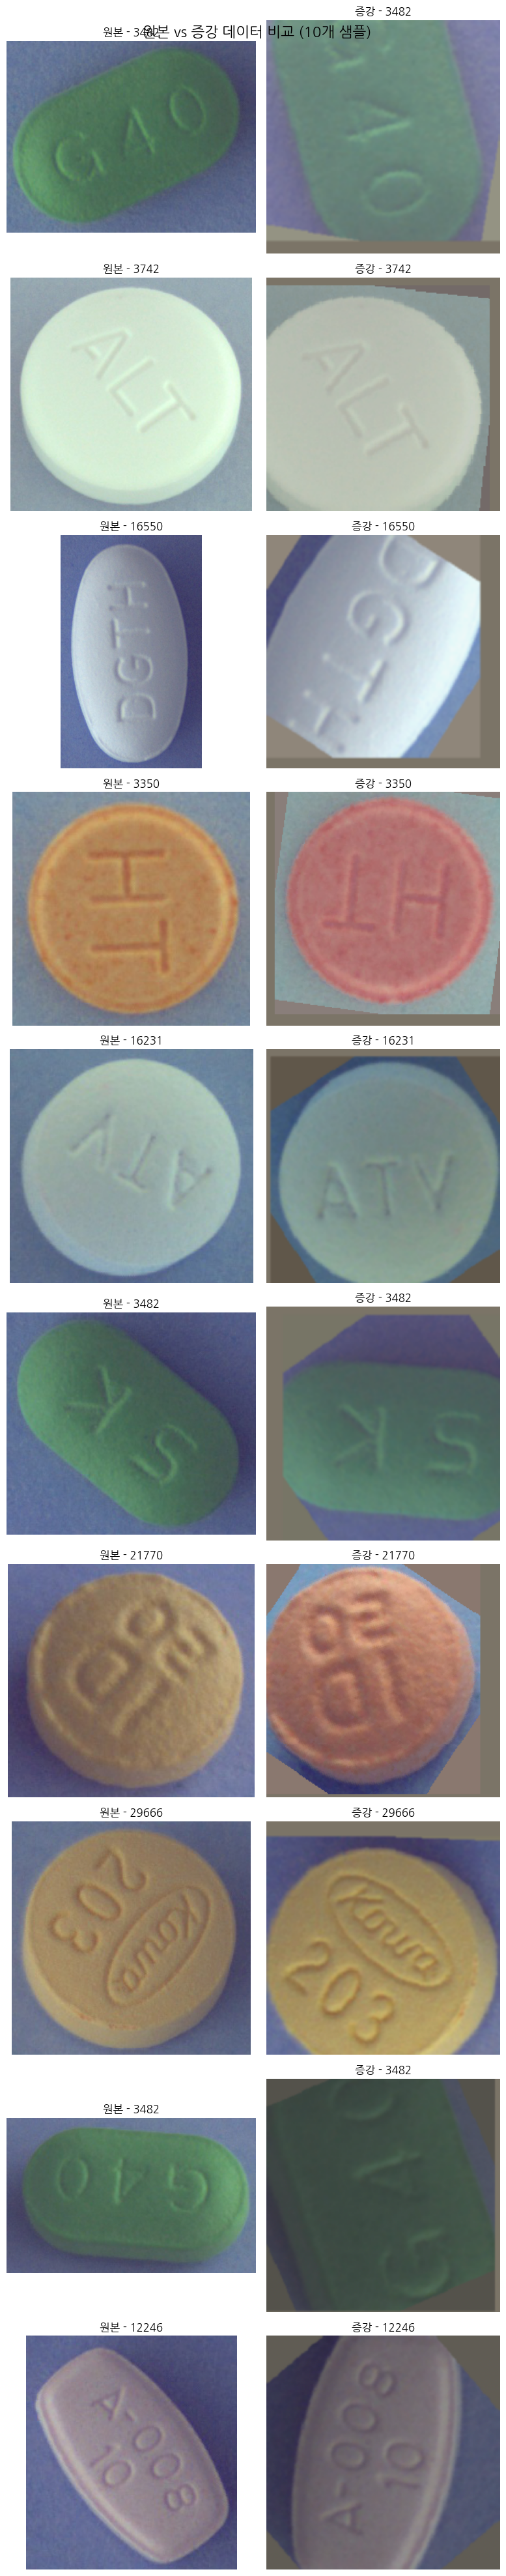

총 10개의 샘플을 표시했습니다.
원본 데이터셋 크기: 3134 samples

표시된 샘플의 클래스 분포:
  3350: 1개
  3482: 3개
  3742: 1개
  12246: 1개
  16231: 1개
  16550: 1개
  21770: 1개
  29666: 1개


In [29]:
# 사용 예시
print("=== 원본 vs 증강 데이터 비교 ===")
visualize_original_vs_augmented_samples(yaml_path, num_rows=10)


In [30]:
raise ValueError("학습 중단 - 필요시 위 코드 참고하여 학습 진행")

ValueError: 학습 중단 - 필요시 위 코드 참고하여 학습 진행

In [31]:
def convert_yolo_to_coco_format(train_dataset, val_dataset, test_dataset, output_dir, image_format='jpg'):
    """
    YOLO 데이터셋을 COCO 형식으로 변환하여 저장하는 함수
    
    Args:
        train_dataset: YOLOToClassificationDataset (train)
        val_dataset: YOLOToClassificationDataset (val) 
        test_dataset: YOLOToClassificationDataset (test)
        output_dir: 출력 폴더 경로
        image_format: 저장할 이미지 형식 ('jpg' 또는 'png')
    """
    import json
    from datetime import datetime
    
    # 출력 디렉토리 구조 생성
    os.makedirs(output_dir, exist_ok=True)
    
    # COCO 형식 기본 구조
    def create_coco_structure(description, split_name):
        return {
            "info": {
                "description": description,
                "url": "",
                "version": "1.0",
                "year": datetime.now().year,
                "contributor": "YOLO to COCO Converter",
                "date_created": datetime.now().isoformat()
            },
            "licenses": [
                {
                    "id": 1,
                    "name": "Unknown License",
                    "url": ""
                }
            ],
            "images": [],
            "annotations": [],
            "categories": []
        }
    
    # 각 분할별로 처리
    datasets_info = [
        (train_dataset, 'train', 'Training dataset'),
        (val_dataset, 'val', 'Validation dataset'), 
        (test_dataset, 'test', 'Test dataset')
    ]
    
    for dataset, split_name, description in datasets_info:
        if dataset is None or len(dataset) == 0:
            print(f"⚠️  {split_name} 데이터셋이 비어있거나 None입니다. 건너뜁니다.")
            continue
            
        print(f"🔄 {split_name} 데이터셋 변환 중... ({len(dataset)} samples)")
        
        # COCO 구조 초기화
        coco_data = create_coco_structure(description, split_name)
        
        # 이미지 및 주석 디렉토리 생성
        images_dir = os.path.join(output_dir, f'{split_name}2017')
        os.makedirs(images_dir, exist_ok=True)
        
        # 카테고리 정보 추가 (한 번만)
        if hasattr(dataset, 'class_names'):
            class_names = dataset.class_names
        elif hasattr(dataset, 'dataset') and hasattr(dataset.dataset, 'class_names'):
            # ConcatDataset의 경우
            for ds in dataset.datasets:
                if hasattr(ds, 'class_names'):
                    class_names = ds.class_names
                    break
                elif hasattr(ds, 'dataset') and hasattr(ds.dataset, 'class_names'):
                    class_names = ds.dataset.class_names
                    break
        else:
            class_names = [f"class_{i}" for i in range(10)]  # 기본값
            
        for i, class_name in enumerate(class_names):
            coco_data["categories"].append({
                "id": i,
                "name": class_name,
                "supercategory": "pill"
            })
        
        # 이미지별 그룹핑을 위한 딕셔너리
        image_groups = {}
        annotation_id = 1
        
        # 모든 샘플을 순회하며 이미지별로 그룹핑
        print(f"📊 {split_name} 샘플들을 이미지별로 그룹핑 중...")
        pbar = tqdm(range(len(dataset)), desc=f"Processing {split_name}")
        
        for idx in pbar:
            try:
                # 데이터셋 타입에 따른 처리
                if hasattr(dataset, 'get_item'):
                    # 원본 YOLOToClassificationDataset
                    crop_image, class_id, original_image_path, bbox = dataset.get_item(idx)
                elif hasattr(dataset, 'dataset') and hasattr(dataset.dataset, 'get_item'):
                    # ConcatDataset 내부의 원본 데이터셋 접근
                    # 복잡하므로 원본 이미지 정보 추출
                    crop_image, class_id = dataset[idx]
                    # 원본 경로는 별도로 처리 필요
                    original_image_path = f"unknown_{idx}.jpg"
                    bbox = [0, 0, 224, 224]  # 기본값
                else:
                    crop_image, class_id = dataset[idx]
                    original_image_path = f"sample_{idx}.jpg"
                    bbox = [0, 0, 224, 224]
                
                # 이미지 파일명 생성
                base_filename = os.path.basename(original_image_path).replace('.jpg', '').replace('.png', '')
                image_filename = f"{base_filename}_{class_id:03d}_{idx:06d}.{image_format}"
                image_path = os.path.join(images_dir, image_filename)
                
                # crop된 이미지 저장
                if isinstance(crop_image, torch.Tensor):
                    # 정규화 해제
                    if crop_image.shape[0] == 3:  # (C, H, W)
                        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
                        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
                        crop_image = crop_image * std + mean
                        crop_image = torch.clamp(crop_image, 0, 1)
                    crop_image = TF.to_pil_image(crop_image)
                
                # 이미지 저장
                crop_image.save(image_path)
                crop_width, crop_height = crop_image.size
                
                # COCO 이미지 정보 추가
                image_info = {
                    "id": idx + 1,
                    "width": crop_width,
                    "height": crop_height,
                    "file_name": image_filename,
                    "license": 1,
                    "flickr_url": "",
                    "coco_url": "",
                    "date_captured": datetime.now().isoformat()
                }
                coco_data["images"].append(image_info)
                
                # COCO 주석 정보 추가 (전체 이미지가 해당 클래스)
                annotation_info = {
                    "id": annotation_id,
                    "image_id": idx + 1,
                    "category_id": class_id,
                    "segmentation": [],
                    "area": crop_width * crop_height,
                    "bbox": [0, 0, crop_width, crop_height],  # 전체 이미지
                    "iscrowd": 0
                }
                coco_data["annotations"].append(annotation_info)
                annotation_id += 1
                
                pbar.set_postfix_str(f'{class_names[class_id]} ({image_filename})')
                
            except Exception as e:
                print(f"⚠️  샘플 {idx} 처리 중 오류: {e}")
                continue
        
        # JSON 파일 저장
        json_filename = f"instances_{split_name}2017.json"
        json_path = os.path.join(output_dir, json_filename)
        
        with open(json_path, 'w', encoding='utf-8') as f:
            json.dump(coco_data, f, indent=2, ensure_ascii=False)
        
        print(f"✅ {split_name} 변환 완료:")
        print(f"   📁 이미지: {len(coco_data['images'])}개 → {images_dir}")
        print(f"   📄 주석: {json_path}")
        print(f"   🏷️  카테고리: {len(coco_data['categories'])}개")

def test_coco_dataset_loading(coco_root_dir):
    """
    변환된 COCO 데이터셋 로딩 테스트
    
    Args:
        coco_root_dir: COCO 형식으로 변환된 데이터가 있는 루트 디렉토리
    """
    print("🧪 COCO 데이터셋 로딩 테스트...")
    
    splits = ['train', 'val', 'test']
    
    for split in splits:
        image_folder = os.path.join(coco_root_dir, f'{split}2017')
        annotation_file = os.path.join(coco_root_dir, f'instances_{split}2017.json')
        
        if not os.path.exists(image_folder) or not os.path.exists(annotation_file):
            print(f"⚠️  {split} 데이터가 없습니다. 건너뜁니다.")
            continue
        
        try:
            # CocoDetection 데이터셋 생성
            dataset = CocoDetection(root=image_folder, annFile=annotation_file)
            
            print(f"✅ {split} 데이터셋 로딩 성공:")
            print(f"   📊 총 이미지 수: {len(dataset)}")
            
            if len(dataset) > 0:
                # 첫 번째 샘플 테스트
                image, target = dataset[0]
                print(f"   🖼️  첫 번째 이미지 크기: {image.size}")
                print(f"   🏷️  주석 개수: {len(target)}")
                if len(target) > 0:
                    print(f"   📝 첫 번째 주석: {target[0]}")
            
            print()
            
        except Exception as e:
            print(f"❌ {split} 데이터셋 로딩 실패: {e}")



In [32]:
def save_augmented_datasets_as_coco_format():
    """
    현재 생성된 증강 데이터셋들을 COCO 형식으로 저장하는 함수
    (새로운 증강 없이 기존 증강된 데이터셋 사용)
    """
    
    # 출력 디렉토리 설정
    output_dir = os.path.join(os.path.dirname(yaml_path), "coco_format_augmented")
    
    print("🚀 증강된 YOLO 데이터셋을 COCO 형식으로 변환 시작...")
    print(f"📁 출력 디렉토리: {output_dir}")
    print(f"📊 증강된 학습 데이터셋 크기: {len(train_dataset)} samples")
    print(f"📊 검증 데이터셋 크기: {len(val_dataset)} samples")
    
    # 기존의 convert_yolo_to_coco_format 함수 사용 (증강된 데이터셋과 함께)
    convert_yolo_to_coco_format(
        train_dataset=train_dataset,      # 이미 증강된 ConcatDataset
        val_dataset=val_dataset,          # 원본 검증 데이터셋
        test_dataset=None,
        output_dir=output_dir,
        image_format='jpg'
    )
    
    print("🎉 증강된 데이터셋 COCO 변환 완료!")
    
    # 로딩 테스트
    test_coco_dataset_loading(output_dir)
    
    # 디렉토리 구조 출력
    print("📂 생성된 디렉토리 구조:")
    print_dir_tree(output_dir, max_depth=2)
    
    return output_dir

def save_original_datasets_as_coco_format():
    """
    원본 데이터셋들을 COCO 형식으로 저장하는 함수 (증강 없이)
    """
    
    # 출력 디렉토리 설정
    output_dir = os.path.join(os.path.dirname(yaml_path), "coco_format_original")
    
    print("🚀 원본 YOLO 데이터셋을 COCO 형식으로 변환 시작...")
    print(f"📁 출력 디렉토리: {output_dir}")
    
    # 원본 데이터셋 생성 (transform 없이 순수 이미지만)
    original_train_dataset = YOLOToClassificationDataset(
        yaml_path=yaml_path,
        split='train',
        transform=None
    )
    
    original_val_dataset = YOLOToClassificationDataset(
        yaml_path=yaml_path, 
        split='val',
        transform=None
    )
    
    original_test_dataset = YOLOToClassificationDataset(
        yaml_path=yaml_path,
        split='test', 
        transform=None
    )
    
    print(f"📊 원본 학습 데이터셋 크기: {len(original_train_dataset)} samples")
    print(f"📊 원본 검증 데이터셋 크기: {len(original_val_dataset)} samples") 
    print(f"📊 원본 테스트 데이터셋 크기: {len(original_test_dataset)} samples")
    
    # COCO 형식으로 변환
    convert_yolo_to_coco_format(
        train_dataset=original_train_dataset,
        val_dataset=original_val_dataset, 
        test_dataset=original_test_dataset,
        output_dir=output_dir,
        image_format='jpg'
    )
    
    print("🎉 원본 데이터셋 COCO 변환 완료!")
    
    # 로딩 테스트
    test_coco_dataset_loading(output_dir)
    
    return output_dir

def compare_datasets_info():
    """
    원본 데이터셋과 증강 데이터셋의 정보를 비교하는 함수
    """
    print("=" * 60)
    print("📊 데이터셋 비교 분석")
    print("=" * 60)
    
    # 원본 데이터셋 생성
    original_train_dataset = YOLOToClassificationDataset(
        yaml_path=yaml_path,
        split='train',
        transform=None
    )
    
    print("📋 원본 학습 데이터셋:")
    print(f"   총 샘플 수: {len(original_train_dataset):,}")
    original_class_counts, _ = analyze_class_distribution(original_train_dataset)
    
    print("\n📋 증강된 학습 데이터셋:")
    print(f"   총 샘플 수: {len(train_dataset):,}")
    print(f"   증가 비율: {len(train_dataset) / len(original_train_dataset):.2f}x")
    
    print("\n📋 검증 데이터셋:")
    print(f"   총 샘플 수: {len(val_dataset):,}")
    
    return original_train_dataset

# 실행
print("=" * 80)
print("🔄 증강된 데이터셋과 원본 데이터셋을 모두 COCO 형식으로 변환합니다...")
print("=" * 80)

# 데이터셋 정보 비교
original_train = compare_datasets_info()

# 1. 증강된 데이터셋을 COCO 형식으로 저장
print("\n" + "=" * 50)
print("🎯 1단계: 증강된 데이터셋 저장")
print("=" * 50)
coco_augmented_dir = save_augmented_datasets_as_coco_format()

# 2. 원본 데이터셋을 COCO 형식으로 저장 (비교용)
print("\n" + "=" * 50) 
print("🎯 2단계: 원본 데이터셋 저장 (비교용)")
print("=" * 50)
coco_original_dir = save_original_datasets_as_coco_format()

print("\n" + "=" * 80)
print("✅ 모든 변환 완료!")
print("=" * 80)
print(f"📁 증강된 데이터셋 COCO: {coco_augmented_dir}")
print(f"📁 원본 데이터셋 COCO: {coco_original_dir}")
print()
print("🚀 이제 다음과 같이 사용할 수 있습니다:")
print("""
# 증강된 학습 데이터 사용
train_coco_augmented = CocoDetection(
    root=f'{coco_augmented_dir}/train2017',
    annFile=f'{coco_augmented_dir}/instances_train2017.json'
)

# 원본 학습 데이터 사용  
train_coco_original = CocoDetection(
    root=f'{coco_original_dir}/train2017',
    annFile=f'{coco_original_dir}/instances_train2017.json'
)
""")

🔄 증강된 데이터셋과 원본 데이터셋을 모두 COCO 형식으로 변환합니다...
📊 데이터셋 비교 분석
yaml_data_path: d:\temp\code_it_ai04\yolo_noresize.zip.unzip
📋 원본 학습 데이터셋:
   총 샘플 수: 3,134


클래스 분포 분석 중: 100%|██████████| 3134/3134 [01:23<00:00, 37.65it/s]


클래스 분포 분석
전체 샘플 수: 3134
클래스 수: 73
최대 샘플 수: 360
최소 샘플 수: 3
불균형 비율: 120.00:1

클래스별 분포:
  3482:  360 samples ( 11.5%)
  3350:  167 samples (  5.3%)
  1899:  136 samples (  4.3%)
  2482:  111 samples (  3.5%)
  16547:  101 samples (  3.2%)
  16550:   92 samples (  2.9%)
  29666:   85 samples (  2.7%)
  35205:   82 samples (  2.6%)
  16231:   76 samples (  2.4%)
  20237:   74 samples (  2.4%)
  16261:   73 samples (  2.3%)
  36636:   72 samples (  2.3%)
  3543:   68 samples (  2.2%)
  27776:   67 samples (  2.1%)
  22346:   65 samples (  2.1%)
  27732:   65 samples (  2.1%)
  25366:   64 samples (  2.0%)
  31884:   59 samples (  1.9%)
  28762:   58 samples (  1.9%)
  34596:   55 samples (  1.8%)
  30307:   54 samples (  1.7%)
  27652:   52 samples (  1.7%)
  20876:   50 samples (  1.6%)
  25468:   48 samples (  1.5%)
  19860:   45 samples (  1.4%)
  5093:   43 samples (  1.4%)
  25437:   39 samples (  1.2%)
  3742:   37 samples (  1.2%)
  33008:   28 samples (  0.9%)
  19551:   28 samples (

Processing train:   0%|          | 6/27473 [00:00<25:10, 18.18it/s, class_0 (sample_6_000_000006.jpg)]  

⚠️  샘플 1 처리 중 오류: list index out of range
⚠️  샘플 2 처리 중 오류: list index out of range
⚠️  샘플 4 처리 중 오류: list index out of range
⚠️  샘플 5 처리 중 오류: list index out of range
⚠️  샘플 7 처리 중 오류: list index out of range
⚠️  샘플 8 처리 중 오류: list index out of range


...

Processing train:  69%|██████▊   | 18839/27473 [19:12<10:15, 14.02it/s, class_6 (sample_13621_006_013621.jpg)]

⚠️  샘플 18835 처리 중 오류: list index out of range
⚠️  샘플 18836 처리 중 오류: list index out of range
⚠️  샘플 18837 처리 중 오류: list index out of range
⚠️  샘플 18838 처리 중 오류: list index out of range


Processing train:  69%|██████▊   | 18840/27473 [19:12<08:47, 16.35it/s, class_6 (sample_13621_006_013621.jpg)]


⚠️  샘플 18839 처리 중 오류: list index out of range


KeyboardInterrupt: 

In [ ]:
def save_augmented_datasets_as_coco_format():
    """
    현재 생성된 증강 데이터셋들을 COCO 형식으로 저장하는 함수
    (새로운 증강 없이 기존 증강된 데이터셋 사용)
    """
    
    # 출력 디렉토리 설정
    output_dir = os.path.join(os.path.dirname(yaml_path), "coco_format_augmented")
    
    print("🚀 증강된 YOLO 데이터셋을 COCO 형식으로 변환 시작...")
    print(f"📁 출력 디렉토리: {output_dir}")
    print(f"📊 증강된 학습 데이터셋 크기: {len(train_dataset)} samples")
    print(f"📊 검증 데이터셋 크기: {len(val_dataset)} samples")
    
    # 기존의 convert_yolo_to_coco_format 함수 사용 (증강된 데이터셋과 함께)
    convert_yolo_to_coco_format(
        train_dataset=train_dataset,      # 이미 증강된 ConcatDataset
        val_dataset=val_dataset,          # 원본 검증 데이터셋
        test_dataset=None,
        output_dir=output_dir,
        image_format='jpg'
    )
    
    print("🎉 증강된 데이터셋 COCO 변환 완료!")
    
    # 로딩 테스트
    test_coco_dataset_loading(output_dir)
    
    # 디렉토리 구조 출력
    print("📂 생성된 디렉토리 구조:")
    print_dir_tree(output_dir, max_depth=2)
    
    return output_dir

def save_original_datasets_as_coco_format():
    """
    원본 데이터셋들을 COCO 형식으로 저장하는 함수 (증강 없이)
    """
    
    # 출력 디렉토리 설정
    output_dir = os.path.join(os.path.dirname(yaml_path), "coco_format_original")
    
    print("🚀 원본 YOLO 데이터셋을 COCO 형식으로 변환 시작...")
    print(f"📁 출력 디렉토리: {output_dir}")
    
    # 원본 데이터셋 생성 (transform 없이 순수 이미지만)
    original_train_dataset = YOLOToClassificationDataset(
        yaml_path=yaml_path,
        split='train',
        transform=None
    )
    
    original_val_dataset = YOLOToClassificationDataset(
        yaml_path=yaml_path, 
        split='val',
        transform=None
    )
    
    original_test_dataset = YOLOToClassificationDataset(
        yaml_path=yaml_path,
        split='test', 
        transform=None
    )
    
    print(f"📊 원본 학습 데이터셋 크기: {len(original_train_dataset)} samples")
    print(f"📊 원본 검증 데이터셋 크기: {len(original_val_dataset)} samples") 
    print(f"📊 원본 테스트 데이터셋 크기: {len(original_test_dataset)} samples")
    
    # COCO 형식으로 변환
    convert_yolo_to_coco_format(
        train_dataset=original_train_dataset,
        val_dataset=original_val_dataset, 
        test_dataset=original_test_dataset,
        output_dir=output_dir,
        image_format='jpg'
    )
    
    print("🎉 원본 데이터셋 COCO 변환 완료!")
    
    # 로딩 테스트
    test_coco_dataset_loading(output_dir)
    
    return output_dir

def compare_datasets_info():
    """
    원본 데이터셋과 증강 데이터셋의 정보를 비교하는 함수
    """
    print("=" * 60)
    print("📊 데이터셋 비교 분석")
    print("=" * 60)
    
    # 원본 데이터셋 생성
    original_train_dataset = YOLOToClassificationDataset(
        yaml_path=yaml_path,
        split='train',
        transform=None
    )
    
    print("📋 원본 학습 데이터셋:")
    print(f"   총 샘플 수: {len(original_train_dataset):,}")
    original_class_counts, _ = analyze_class_distribution(original_train_dataset)
    
    print("\n📋 증강된 학습 데이터셋:")
    print(f"   총 샘플 수: {len(train_dataset):,}")
    print(f"   증가 비율: {len(train_dataset) / len(original_train_dataset):.2f}x")
    
    print("\n📋 검증 데이터셋:")
    print(f"   총 샘플 수: {len(val_dataset):,}")
    
    return original_train_dataset

# 실행
print("=" * 80)
print("🔄 증강된 데이터셋과 원본 데이터셋을 모두 COCO 형식으로 변환합니다...")
print("=" * 80)

# 데이터셋 정보 비교
original_train = compare_datasets_info()

# 1. 증강된 데이터셋을 COCO 형식으로 저장
print("\n" + "=" * 50)
print("🎯 1단계: 증강된 데이터셋 저장")
print("=" * 50)
coco_augmented_dir = save_augmented_datasets_as_coco_format()

# 2. 원본 데이터셋을 COCO 형식으로 저장 (비교용)
print("\n" + "=" * 50) 
print("🎯 2단계: 원본 데이터셋 저장 (비교용)")
print("=" * 50)
coco_original_dir = save_original_datasets_as_coco_format()

print("\n" + "=" * 80)
print("✅ 모든 변환 완료!")
print("=" * 80)
print(f"📁 증강된 데이터셋 COCO: {coco_augmented_dir}")
print(f"📁 원본 데이터셋 COCO: {coco_original_dir}")
print()
print("🚀 이제 다음과 같이 사용할 수 있습니다:")
print("""
# 증강된 학습 데이터 사용
train_coco_augmented = CocoDetection(
    root=f'{coco_augmented_dir}/train2017',
    annFile=f'{coco_augmented_dir}/instances_train2017.json'
)

# 원본 학습 데이터 사용  
train_coco_original = CocoDetection(
    root=f'{coco_original_dir}/train2017',
    annFile=f'{coco_original_dir}/instances_train2017.json'
)
""")

In [ ]:
# raise ValueError("중단")